# Using Atmospheric Models and Evolutionary Grids for inversions


The objective of this notebook is to show how different grids of evolutionary models of exoplanets can be used to infer the mass of exoplanets from their flux. `oplanet` and its `ExoPlInversion` class unify different grids ([Sonora](https://zenodo.org/records/5063476), [Linder](http://cdsarc.u-strasbg.fr/ftp/J/A+A/623/A85/cooling_curves/), [ATMO](https://perso.ens-lyon.fr/isabelle.baraffe/ATMO2020/) and Hades) in one single sturcture. Inversions can thus be performed through linear interpolation.

References:
- [Phillips et al. 2020](https://www.aanda.org/articles/aa/pdf/2020/05/aa37381-19.pdf)
- [Linder et al. 2019](https://www.aanda.org/articles/aa/full_html/2019/03/aa33873-18/aa33873-18.html)
- [Marley et al. 2021](https://doi.org/10.5281/zenodo.5063475)

In [1]:
from oplanet import EInversion, NSystem
from oakley import *

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

First, let's test our inversion scheme on known systems. The inversion will typically be used from photmetry to mass, but here we will try to invert mass from intrinsic temeprature instead, as the latter are easier to find in the litterature.

___
## 1. Retrieving test data

In [38]:
# 1. Get the temperatures
planets_df = pd.DataFrame({
    "planet": [
        "beta Pic b", "51 Eri b","HR 8799 b", "HR 8799 c", "HR 8799 d",
        "HR 8799 e", "HIP 65426 b", "PDS 70 b", "PDS 70 c", "2M1207 b",
        "GJ 504 b", "HIP 99770 b", "TWA 7b", "Eps Ind b"
    ], # all self-luminous planets
    "t_int_k": [1700,700,1000,1100,1100,1200,1300,1100,1000,1000,550,1300, 300, 200],
})

For these planets, we want the age of the system as well as the known mass of the planet. Let's take one of them as an example.

In [39]:
nsystem = NSystem("HR 8799")
nsystem.star.display()

[i] Star HR 8799 properties:
 > Age (Myr):                               [ 60. 100. -30.]
 > Mass (solar masses):                     [ 1.5  0.3 -0.3]
 > Radius (solar radii):                    [nan nan nan]
 > Luminosity (solar luminosities):         [ 0.69197  0.03476 -0.03779]
 > Effective temperature (K):               [nan nan nan]
 > Irradiation temparature at 1 arcsec (K): [nan nan nan]
 > Metallicity (dex):                       [-0.47   nan   nan]
 > Spectral type:                           nan
 > Reference:                               Marois et al. 2008
 > Row:                                     1/15


Too bad, the age is not present here! However, it is elsewhere in the archive, but `oplanet` simply ignored it because other fields were missing. Let's tell `oplanet` that we are most interested in the age of the system!

In [40]:
nsystem.add_property_priority("star.age_myr", 10)
nsystem.star.display()

[i] Star HR 8799 properties:
 > Age (Myr):                               [ 60. 100. -30.]
 > Mass (solar masses):                     [ 1.5  0.3 -0.3]
 > Radius (solar radii):                    [nan nan nan]
 > Luminosity (solar luminosities):         [ 0.69197  0.03476 -0.03779]
 > Effective temperature (K):               [nan nan nan]
 > Irradiation temparature at 1 arcsec (K): [nan nan nan]
 > Metallicity (dex):                       [-0.47   nan   nan]
 > Spectral type:                           nan
 > Reference:                               Marois et al. 2008
 > Row:                                     1/15


Now let's add masses and ages for all planets!

In [41]:
# 2. Add ages and masses*
for planet_name in ProgressBar(planets_df["planet"]):
    system_name = planet_name[:-1].strip()
    planet_letter = planet_name[-1]
    nsystem = NSystem(system_name)
    star = nsystem.star
    planet = nsystem._get_planet(planet_letter)
    planet.set_config(properties = {"mass_mjup": 10})
    
    age_myr = star.age_myr[0]
    age_myr_upper = age_myr + star.age_myr[1]
    age_myr_lower = age_myr + star.age_myr[2]
    mass_mjup = planet.mass_mjup[0]
    mass_mjup_upper = mass_mjup + planet.mass_mjup[1]
    mass_mjup_lower = mass_mjup + planet.mass_mjup[2]
    planets_df.loc[planets_df["planet"] == planet_name, "age_myr"] = age_myr
    planets_df.loc[planets_df["planet"] == planet_name, "age_myr_upper"] = age_myr_upper
    planets_df.loc[planets_df["planet"] == planet_name, "age_myr_lower"] = age_myr_lower
    planets_df.loc[planets_df["planet"] == planet_name, "mass_mjup"] = mass_mjup
    planets_df.loc[planets_df["planet"] == planet_name, "mass_mjup_upper"] = mass_mjup_upper
    planets_df.loc[planets_df["planet"] == planet_name, "mass_mjup_lower"] = mass_mjup_lower
planets_df["metallicity_solar_dex"] = 0 

[%] [1.477s > 0.000s, 9.48 it/s, 14/14]                                              


Let's take a look at our dataframe!

In [42]:
planets_df.describe()

,t_int_k,age_myr,age_myr_upper,age_myr_lower,mass_mjup,mass_mjup_upper,mass_mjup_lower,metallicity_solar_dex
count,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.0
mean,967.857143,388.921429,525.650000,292.814286,6.642143,9.138571,4.755714,0.0
std,406.489258,1242.926555,1497.598688,981.249535,4.261502,5.961226,2.923551,0.0
min,200.000000,5.400000,6.400000,4.400000,0.340000,0.400000,0.280000,0.0
25%,775.000000,11.000000,13.500000,8.500000,3.437500,4.125000,2.700000,0.0
50%,1050.000000,41.600000,92.450000,25.600000,6.100000,9.550000,4.750000,0.0
75%,1175.000000,60.000000,160.000000,30.000000,9.750000,12.750000,6.750000,0.0
max,1700.000000,4700.000000,5700.000000,3700.000000,16.100000,21.500000,11.100000,0.0


Great! Let's make a plot of our planets in mass/age space colored by temperature, with error bars.

___
## Model comparison

In the cell below, the method for the inversion is shown:
```python
exi = EInversion(
    model,
    scheme="t,a,z => m" # t=temperature, a=age myr, z=met_dex, m=mass_mjup
)
mass, *_ = exi(t_int, age, 0)
```

[~] Creating plot...
 > [00%] ━━━━━━━━━━━━━━━━━━━━━━━━━

 > [%] [14.230s > 0.000s, 59.0 it/min, 14/14]                                               
 > [~] Task completed after: 14.284s


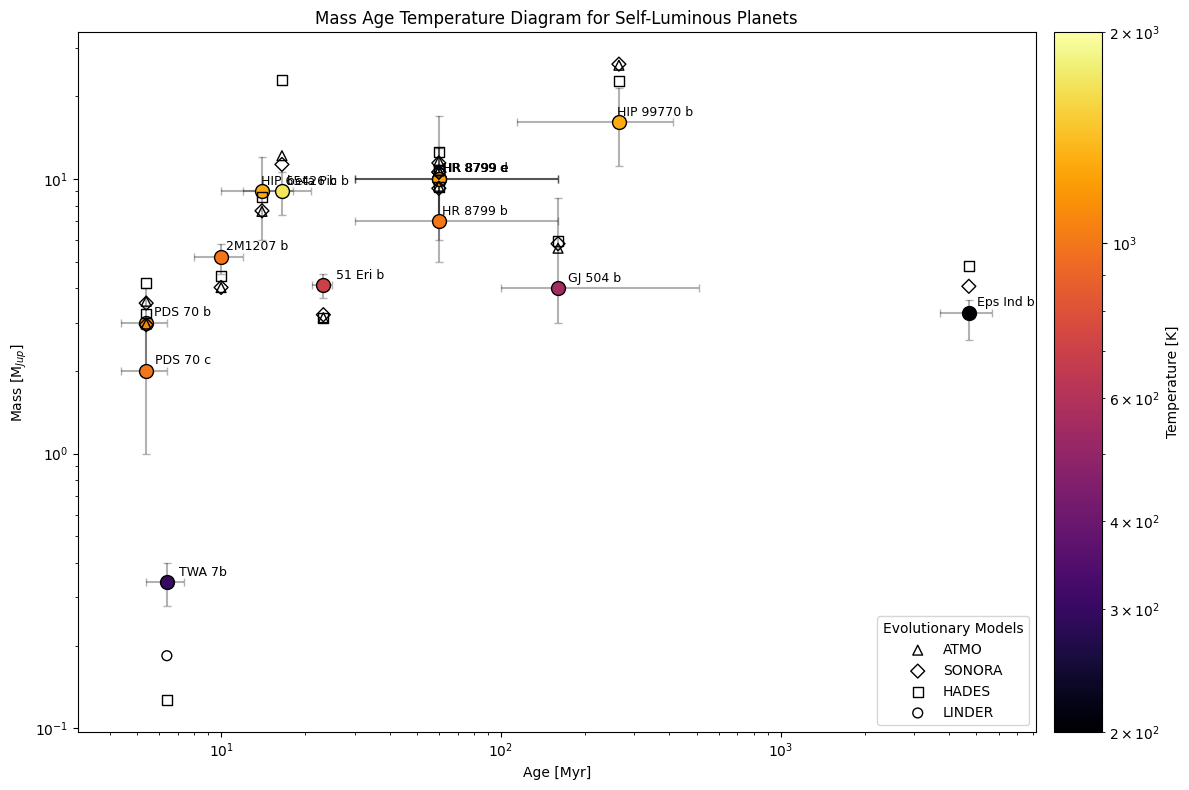

In [44]:
# 1. Prepare the figure
plt.figure(figsize=(12, 8))
from matplotlib.gridspec import GridSpec
gs = GridSpec(1, 2, width_ratios=[1, 0.05])
plt.subplot(gs[0, 0])
plt.title("Mass Age Temperature Diagram for Self-Luminous Planets")

cmap = plt.cm.inferno
from matplotlib.colors import LogNorm
norm = LogNorm(vmin=200, vmax=2000)

with Task("Creating plot..."):
    for row in ProgressBar(list(planets_df.itertuples())):
        # 2. Collect info for each planet
        age = row.age_myr
        age_upper = row.age_myr_upper
        age_lower = row.age_myr_lower
        mass = row.mass_mjup
        mass_upper = row.mass_mjup_upper
        mass_lower = row.mass_mjup_lower
        t_int = row.t_int_k

        # 3. Plot error bars first
        plt.errorbar(
            x=age, y=mass,
            xerr=[[age - age_lower], [age_upper - age]],
            yerr=[[mass - mass_lower], [mass_upper - mass]],
            fmt="none",
            ecolor="k",
            capsize=3,
            zorder=1,
            alpha=0.3
        )

        # 4. Plot the point with color based on temperature
        plt.scatter(
            x=age, y=mass,
            c=[t_int], cmap=cmap, norm=norm,
            s=100, edgecolor="k", zorder=2,
        )

        # 5. Add the planet name
        plt.text(
            x=age*1.35, y=mass*1.03,
            s=row.planet,
            fontsize=9,
            ha="center", va="bottom",
            zorder=3,
        )

        # 6. For each model, invert mass based on age and temperature
        models = ["ATMO", "SONORA", "HADES", "LINDER"]
        markers = ["^", "D", "s", "o"]
        for model in models:
            exi = EInversion(
                model,
                scheme="t,a,z -> m"
            )
            mass, *_ = exi(t_int, age, 0)

            plt.scatter(
                x=age, y=mass,
                marker=markers[models.index(model)],
                s=50, edgecolor="k", facecolor="none",
                zorder=4,
            )


# 7. Add a colorbar for temperature on the second subplot
plt.subplot(gs[0, 1])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=plt.gca())
cbar.set_label("Temperature [K]")

plt.subplot(gs[0, 0])
# 8. Add the legend for the models
for model, marker in zip(models, markers):
    plt.scatter([], [], marker=marker, s=50, edgecolor="k", facecolor="none", label=model)
plt.legend(title="Evolutionary Models", loc="lower right")

plt.xlabel("Age [Myr]")
plt.ylabel("Mass [M$_{Jup}$]")
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()

plt.show()

Models don't appear to be that good at predicting stuff. Espacially HADES for some reason. In need to look into it.